# 07. Frequency-Domain Features & Correlation Analysis

## Objective

This notebook extracts frequency-domain wearable features from the preprocessed Parkinson's Disease Smartwatch Dataset (PADS) recordings and identifies strongly correlated features.

It follows the established preprocessing pipeline by reading the participant-level compressed `.npz` files produced after:

1. L1 trend filtering of accelerometer axes using `λ = 50`.
2. CLARABEL optimization.
3. Removal of the first 48 samples.
4. Re-zeroing of the time channel.
5. Preservation of gyroscope signals.
6. Calculation of accelerometer and gyroscope magnitudes.

The notebook produces:

- a frequency-domain feature table;
- separate accelerometer and gyroscope feature groups;
- a Pearson correlation matrix;
- a table of strongly correlated wearable features; and
- a summary of the correlation-analysis results.


## Frequency-Domain Features

For each accelerometer and gyroscope axis and magnitude signal, the following features are extracted:

- **Dominant frequency:** frequency with the highest spectral power.
- **Spectral centroid:** power-weighted average frequency.
- **Spectral entropy:** normalized measure of spectral complexity.
- **Spectral power:** total power represented by the one-sided power spectral density.

The analysis includes:

- Accelerometer X, Y, Z, and magnitude.
- Gyroscope X, Y, Z, and magnitude.

This yields 16 accelerometer and 16 gyroscope frequency-domain features per recording.


## Compatibility Note

The feature module supports both newer NumPy versions using `np.trapezoid()` and older versions using `np.trapz()`.


In [15]:
# Libraries and project paths
# =============================================================================

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

cwd = Path.cwd()
if (cwd / "data").exists() and (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists() and (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing data/ and src/."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.frequency_features import (
    build_correlation_summary,
    build_frequency_feature_table,
    compute_feature_correlations,
    get_accelerometer_feature_columns,
    get_frequency_feature_columns,
    get_gyroscope_feature_columns,
    summarize_strong_correlations,
)

NPZ_DIR = PROJECT_ROOT / "data" / "processed" / "preprocessed_signals"
FEATURE_OUTPUT = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "frequency_domain_features.csv"
)
CORRELATION_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "correlation_analysis"
)
CORRELATION_MATRIX_OUTPUT = (
    CORRELATION_OUTPUT_DIR / "frequency_feature_correlation_matrix.csv"
)
STRONG_CORRELATIONS_OUTPUT = (
    CORRELATION_OUTPUT_DIR / "strongly_correlated_features.csv"
)
CORRELATION_SUMMARY_OUTPUT = (
    CORRELATION_OUTPUT_DIR / "correlation_analysis_summary.csv"
)

STRONG_CORRELATION_THRESHOLD = 0.80

print("Project root:", PROJECT_ROOT)
print("Processed NPZ directory:", NPZ_DIR)
print("Frequency feature output:", FEATURE_OUTPUT)
print("Correlation output directory:", CORRELATION_OUTPUT_DIR)


Project root: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease
Processed NPZ directory: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\preprocessed_signals
Frequency feature output: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\frequency_domain_features.csv
Correlation output directory: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis


## 1. Confirm Input Availability

The expected input is one participant-level file per participant in:

`data/processed/preprocessed_signals/`

Each file should follow the pattern `*_preprocessed.npz`.


In [16]:
# Validate the processed-signal input directory
# =============================================================================

if not NPZ_DIR.exists():
    raise FileNotFoundError(
        f"Could not locate {NPZ_DIR}. "
        "Run or obtain the signal-preprocessing outputs before continuing."
    )

npz_files = sorted(NPZ_DIR.glob("*_preprocessed.npz"))

if not npz_files:
    raise FileNotFoundError(
        f"No participant .npz files were found in {NPZ_DIR}."
    )

print("Participant NPZ files found:", len(npz_files))
print("First file:", npz_files[0].name)


Participant NPZ files found: 469
First file: 001_preprocessed.npz


## 2. Inspect the Preprocessed `.npz` Structure

The structure is checked before dataset-wide extraction to confirm that the expected metadata, recording keys, and signal columns are available.


In [17]:
# Inspect one participant file
# =============================================================================

with np.load(npz_files[0], allow_pickle=False) as sample:
    sample_columns = sample["__columns__"].astype(str).tolist()
    sample_recording_keys = (
        sample["__recording_keys__"].astype(str).tolist()
    )
    first_recording_key = sample_recording_keys[0]
    first_recording_shape = sample[first_recording_key].shape

print("Signal columns:", sample_columns)
print("Recordings in sample participant:", len(sample_recording_keys))
print("First recording key:", first_recording_key)
print("First recording shape:", first_recording_shape)

expected_columns = [
    "Time",
    "Accelerometer_X",
    "Accelerometer_Y",
    "Accelerometer_Z",
    "Gyroscope_X",
    "Gyroscope_Y",
    "Gyroscope_Z",
    "Acc_Magnitude",
    "Gyro_Magnitude",
]

missing_columns = [
    column for column in expected_columns if column not in sample_columns
]
print("Required columns missing:", missing_columns)
assert not missing_columns


Signal columns: ['Time', 'Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z', 'Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z', 'Acc_Magnitude', 'Gyro_Magnitude']
Recordings in sample participant: 22
First recording key: CrossArms__LeftWrist
First recording shape: (976, 9)
Required columns missing: []


## 3. Extract Dataset-Wide Frequency-Domain Features

One output row is produced for every participant × task × wrist recording. Sampling frequency is inferred separately from each recording's time channel using the median positive sampling interval.


In [ ]:
# Extract frequency-domain features
# =============================================================================

frequency_features = build_frequency_feature_table(NPZ_DIR)

print("Frequency feature table shape:", frequency_features.shape)
print("Participants:", frequency_features["patient_id"].nunique())
print("Tasks:", frequency_features["task"].nunique())
print("Wrists:", frequency_features["wrist"].nunique())

frequency_features.head()


In [ ]:
# Confirm expected frequency-feature groups
# =============================================================================

all_frequency_columns = get_frequency_feature_columns(frequency_features)
accelerometer_frequency_columns = (
    get_accelerometer_feature_columns(frequency_features)
)
gyroscope_frequency_columns = (
    get_gyroscope_feature_columns(frequency_features)
)

feature_group_summary = pd.DataFrame(
    {
        "feature_group": [
            "Accelerometer",
            "Gyroscope",
            "Total",
        ],
        "number_of_features": [
            len(accelerometer_frequency_columns),
            len(gyroscope_frequency_columns),
            len(all_frequency_columns),
        ],
    }
)

feature_group_summary


,feature_group,number_of_features
0,Accelerometer,16
1,Gyroscope,16
2,Total,32


In [ ]:
# Display accelerometer and gyroscope feature groups
# =============================================================================

print("Accelerometer frequency features:")
for column in accelerometer_frequency_columns:
    print(" -", column)

print("\nGyroscope frequency features:")
for column in gyroscope_frequency_columns:
    print(" -", column)


Accelerometer frequency features:
 - acc_x_dominant_frequency
 - acc_x_spectral_centroid
 - acc_x_spectral_entropy
 - acc_x_spectral_power
 - acc_y_dominant_frequency
 - acc_y_spectral_centroid
 - acc_y_spectral_entropy
 - acc_y_spectral_power
 - acc_z_dominant_frequency
 - acc_z_spectral_centroid
 - acc_z_spectral_entropy
 - acc_z_spectral_power
 - acc_magnitude_dominant_frequency
 - acc_magnitude_spectral_centroid
 - acc_magnitude_spectral_entropy
 - acc_magnitude_spectral_power

Gyroscope frequency features:
 - gyro_x_dominant_frequency
 - gyro_x_spectral_centroid
 - gyro_x_spectral_entropy
 - gyro_x_spectral_power
 - gyro_y_dominant_frequency
 - gyro_y_spectral_centroid
 - gyro_y_spectral_entropy
 - gyro_y_spectral_power
 - gyro_z_dominant_frequency
 - gyro_z_spectral_centroid
 - gyro_z_spectral_entropy
 - gyro_z_spectral_power
 - gyro_magnitude_dominant_frequency
 - gyro_magnitude_spectral_centroid
 - gyro_magnitude_spectral_entropy
 - gyro_magnitude_spectral_power


## 4. Frequency-Feature Quality Assurance

The following checks confirm that identifiers are unique at the recording level and summarize missing or non-finite feature values.


In [ ]:
# Recording-level uniqueness and completeness checks
# =============================================================================

identifier_columns = ["patient_id", "task", "wrist"]
duplicate_recordings = frequency_features.duplicated(
    subset=identifier_columns,
    keep=False,
)

feature_qa = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Unique participant-task-wrist records",
            "Duplicate participant-task-wrist records",
            "Frequency features",
            "Missing frequency-feature values",
            "Infinite frequency-feature values",
        ],
        "value": [
            len(frequency_features),
            frequency_features[identifier_columns]
            .drop_duplicates()
            .shape[0],
            int(duplicate_recordings.sum()),
            len(all_frequency_columns),
            int(
                frequency_features[all_frequency_columns]
                .isna()
                .sum()
                .sum()
            ),
            int(
                np.isinf(
                    frequency_features[all_frequency_columns].to_numpy(
                        dtype=float
                    )
                ).sum()
            ),
        ],
    }
)

feature_qa


,metric,value
0,Rows,10318
1,Unique participant-task-wrist records,10318
2,Duplicate participant-task-wrist records,0
3,Frequency features,32
4,Missing frequency-feature values,0
5,Infinite frequency-feature values,0


In [ ]:
# Feature-level missingness
# =============================================================================

feature_missingness = (
    frequency_features[all_frequency_columns]
    .isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)

feature_missingness["missing_percentage"] = (
    feature_missingness["missing_values"]
    / len(frequency_features)
    * 100
).round(2)

feature_missingness.sort_values(
    "missing_values",
    ascending=False,
).head(20)


,missing_values,missing_percentage
acc_x_dominant_frequency,0,0.0
acc_x_spectral_centroid,0,0.0
gyro_magnitude_spectral_entropy,0,0.0
gyro_magnitude_spectral_centroid,0,0.0
gyro_magnitude_dominant_frequency,0,0.0
gyro_z_spectral_power,0,0.0
gyro_z_spectral_entropy,0,0.0
gyro_z_spectral_centroid,0,0.0
gyro_z_dominant_frequency,0,0.0
gyro_y_spectral_power,0,0.0


## 5. Save the Frequency-Domain Feature Table

The complete table is saved as:

`data/processed/frequency_domain_features.csv`


In [ ]:
# Save and verify frequency-domain feature table
# =============================================================================

FEATURE_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
frequency_features.to_csv(FEATURE_OUTPUT, index=False)

if not FEATURE_OUTPUT.exists() or FEATURE_OUTPUT.stat().st_size == 0:
    raise IOError(
        f"Frequency feature table was not saved correctly: {FEATURE_OUTPUT}"
    )

verified_frequency_features = pd.read_csv(
    FEATURE_OUTPUT,
    dtype={"patient_id": str},
)

assert verified_frequency_features.shape == frequency_features.shape

print("Saved:", FEATURE_OUTPUT)
print("Verified shape:", verified_frequency_features.shape)


Saved: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\frequency_domain_features.csv
Verified shape: (10318, 38)


## 6. Correlation Analysis

Pearson correlations are calculated across the 32 frequency-domain wearable features. Identifier and metadata variables are excluded.

A feature pair is classified as strongly correlated when:

`|r| ≥ 0.80`

The threshold can be changed through `STRONG_CORRELATION_THRESHOLD`.


In [ ]:
# Calculate the correlation matrix
# =============================================================================

correlation_matrix = compute_feature_correlations(
    frequency_features,
    method="pearson",
)

print("Correlation matrix shape:", correlation_matrix.shape)
correlation_matrix.round(3)


Correlation matrix shape: (32, 32)


,acc_x_dominant_frequency,acc_x_spectral_centroid,acc_x_spectral_entropy,acc_x_spectral_power,acc_y_dominant_frequency,acc_y_spectral_centroid,acc_y_spectral_entropy,acc_y_spectral_power,acc_z_dominant_frequency,acc_z_spectral_centroid,acc_z_spectral_entropy,acc_z_spectral_power,acc_magnitude_dominant_frequency,acc_magnitude_spectral_centroid,acc_magnitude_spectral_entropy,acc_magnitude_spectral_power,gyro_x_dominant_frequency,gyro_x_spectral_centroid,gyro_x_spectral_entropy,gyro_x_spectral_power,gyro_y_dominant_frequency,gyro_y_spectral_centroid,gyro_y_spectral_entropy,gyro_y_spectral_power,gyro_z_dominant_frequency,gyro_z_spectral_centroid,gyro_z_spectral_entropy,gyro_z_spectral_power,gyro_magnitude_dominant_frequency,gyro_magnitude_spectral_centroid,gyro_magnitude_spectral_entropy,gyro_magnitude_spectral_power
acc_x_dominant_frequency,1.000,0.611,0.375,-0.117,0.513,0.456,0.177,-0.074,0.554,0.509,0.317,-0.104,0.194,0.535,0.372,-0.077,0.493,0.554,0.349,-0.124,0.457,0.626,0.515,-0.240,0.450,0.613,0.532,-0.222,0.128,0.586,0.501,-0.246
acc_x_spectral_centroid,0.611,1.000,0.799,-0.050,0.506,0.777,0.498,-0.009,0.503,0.723,0.567,0.006,0.138,0.745,0.494,0.068,0.455,0.640,0.435,-0.099,0.344,0.683,0.573,-0.238,0.368,0.664,0.585,-0.230,0.081,0.639,0.526,-0.236
acc_x_spectral_entropy,0.375,0.799,1.000,-0.137,0.368,0.637,0.642,-0.060,0.323,0.559,0.656,-0.050,-0.088,0.473,0.316,0.030,0.259,0.440,0.435,-0.117,0.098,0.417,0.541,-0.341,0.130,0.400,0.500,-0.272,-0.149,0.355,0.365,-0.267
acc_x_spectral_power,-0.117,-0.050,-0.137,1.000,-0.114,-0.007,-0.061,0.684,-0.116,-0.089,-0.152,0.836,0.019,-0.023,0.027,0.797,-0.113,-0.108,-0.162,0.489,-0.040,-0.095,-0.178,0.612,-0.071,-0.115,-0.195,0.509,0.073,-0.098,-0.114,0.551
acc_y_dominant_frequency,0.513,0.506,0.368,-0.114,1.000,0.559,0.254,-0.067,0.531,0.526,0.376,-0.097,0.124,0.463,0.276,-0.060,0.433,0.521,0.307,-0.126,0.334,0.508,0.410,-0.231,0.386,0.543,0.427,-0.219,0.082,0.482,0.363,-0.233
acc_y_spectral_centroid,0.456,0.777,0.637,-0.007,0.559,1.000,0.745,0.029,0.462,0.716,0.627,0.062,0.088,0.730,0.457,0.140,0.376,0.587,0.380,-0.081,0.255,0.551,0.462,-0.161,0.272,0.561,0.470,-0.200,0.040,0.533,0.399,-0.188
acc_y_spectral_entropy,0.177,0.498,0.642,-0.061,0.254,0.745,1.000,-0.053,0.172,0.472,0.683,-0.012,-0.201,0.381,0.265,0.069,0.069,0.263,0.349,-0.103,-0.059,0.198,0.328,-0.164,-0.062,0.198,0.321,-0.192,-0.257,0.139,0.153,-0.170
acc_y_spectral_power,-0.074,-0.009,-0.060,0.684,-0.067,0.029,-0.053,1.000,-0.069,-0.032,-0.087,0.642,0.026,0.018,0.041,0.807,-0.073,-0.061,-0.128,0.541,-0.003,-0.033,-0.100,0.374,-0.039,-0.075,-0.154,0.464,0.084,-0.044,-0.064,0.494
acc_z_dominant_frequency,0.554,0.503,0.323,-0.116,0.531,0.462,0.172,-0.069,1.000,0.634,0.375,-0.104,0.178,0.490,0.309,-0.076,0.418,0.457,0.293,-0.121,0.421,0.594,0.494,-0.238,0.427,0.556,0.444,-0.217,0.120,0.499,0.435,-0.237
acc_z_spectral_centroid,0.509,0.723,0.559,-0.089,0.526,0.716,0.472,-0.032,0.634,1.000,0.780,-0.048,0.082,0.692,0.469,0.025,0.371,0.499,0.396,-0.123,0.316,0.650,0.582,-0.230,0.387,0.645,0.536,-0.229,0.038,0.549,0.501,-0.237


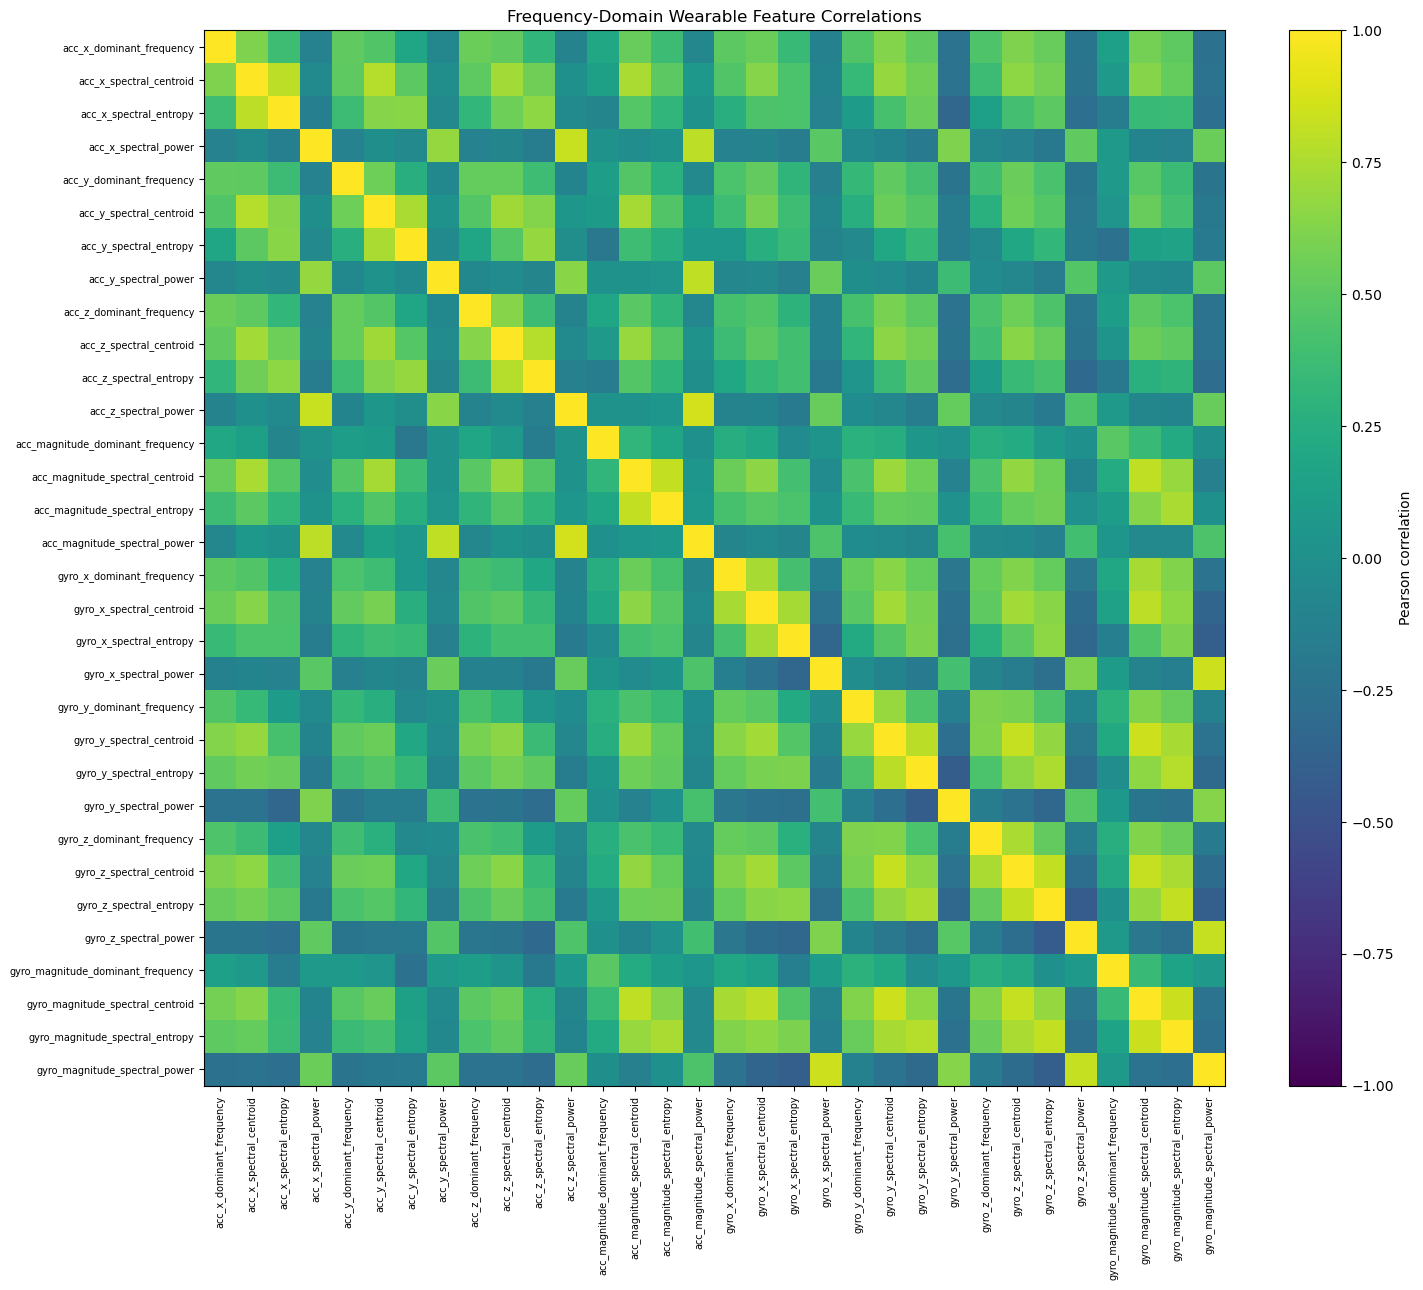

In [ ]:
# Visualize the frequency-feature correlation matrix
# =============================================================================

figure, axis = plt.subplots(figsize=(15, 13))
image = axis.imshow(
    correlation_matrix.to_numpy(),
    aspect="auto",
    vmin=-1,
    vmax=1,
)

axis.set_xticks(range(len(correlation_matrix.columns)))
axis.set_xticklabels(
    correlation_matrix.columns,
    rotation=90,
    fontsize=7,
)
axis.set_yticks(range(len(correlation_matrix.index)))
axis.set_yticklabels(
    correlation_matrix.index,
    fontsize=7,
)
axis.set_title("Frequency-Domain Wearable Feature Correlations")
figure.colorbar(image, ax=axis, label="Pearson correlation")
figure.tight_layout()
plt.show()


## 7. Identify Strongly Correlated Wearable Features

Duplicate and self-correlations are excluded. Each retained pair is classified as:

- accelerometer-only;
- gyroscope-only; or
- cross-sensor.


In [ ]:
# Identify strongly correlated feature pairs
# =============================================================================

strong_correlations = summarize_strong_correlations(
    correlation_matrix,
    threshold=STRONG_CORRELATION_THRESHOLD,
)

print(
    "Strongly correlated pairs:",
    len(strong_correlations),
)
strong_correlations.head(30)


Strongly correlated pairs: 14


,feature_1,feature_2,correlation,absolute_correlation,direction,relationship_group
0,acc_z_spectral_power,acc_magnitude_spectral_power,0.866707,0.866707,Positive,Accelerometer
1,gyro_x_spectral_power,gyro_magnitude_spectral_power,0.849496,0.849496,Positive,Gyroscope
2,gyro_y_spectral_centroid,gyro_magnitude_spectral_centroid,0.844809,0.844809,Positive,Gyroscope
3,gyro_magnitude_spectral_centroid,gyro_magnitude_spectral_entropy,0.843446,0.843446,Positive,Gyroscope
4,acc_x_spectral_power,acc_z_spectral_power,0.835903,0.835903,Positive,Accelerometer
5,gyro_y_spectral_centroid,gyro_z_spectral_centroid,0.825819,0.825819,Positive,Gyroscope
6,gyro_z_spectral_centroid,gyro_magnitude_spectral_centroid,0.822480,0.822480,Positive,Gyroscope
7,gyro_z_spectral_power,gyro_magnitude_spectral_power,0.820593,0.820593,Positive,Gyroscope
8,gyro_z_spectral_centroid,gyro_z_spectral_entropy,0.819117,0.819117,Positive,Gyroscope
9,gyro_z_spectral_entropy,gyro_magnitude_spectral_entropy,0.815344,0.815344,Positive,Gyroscope


In [ ]:
# Summarize strong correlations by relationship group and direction
# =============================================================================

if strong_correlations.empty:
    strong_correlation_group_summary = pd.DataFrame(
        columns=["relationship_group", "direction", "feature_pairs"]
    )
else:
    strong_correlation_group_summary = (
        strong_correlations
        .groupby(
            ["relationship_group", "direction"],
            as_index=False,
        )
        .size()
        .rename(columns={"size": "feature_pairs"})
    )

strong_correlation_group_summary


,relationship_group,direction,feature_pairs
0,Accelerometer,Positive,4
1,Cross-sensor,Positive,1
2,Gyroscope,Positive,9


## 8. Save Correlation Deliverables

The following outputs are saved:

- `outputs/tables/correlation_analysis/frequency_feature_correlation_matrix.csv`
- `outputs/tables/correlation_analysis/strongly_correlated_features.csv`
- `outputs/tables/correlation_analysis/correlation_analysis_summary.csv`


In [ ]:
# Build and save the correlation-analysis summary
# =============================================================================

correlation_summary = build_correlation_summary(
    feature_table=frequency_features,
    strong_correlations=strong_correlations,
    threshold=STRONG_CORRELATION_THRESHOLD,
)

CORRELATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

correlation_matrix.to_csv(CORRELATION_MATRIX_OUTPUT)
strong_correlations.to_csv(
    STRONG_CORRELATIONS_OUTPUT,
    index=False,
)
correlation_summary.to_csv(
    CORRELATION_SUMMARY_OUTPUT,
    index=False,
)

output_paths = [
    CORRELATION_MATRIX_OUTPUT,
    STRONG_CORRELATIONS_OUTPUT,
    CORRELATION_SUMMARY_OUTPUT,
]

for output_path in output_paths:
    if not output_path.exists() or output_path.stat().st_size == 0:
        raise IOError(f"Output was not saved correctly: {output_path}")
    print("Saved:", output_path)

correlation_summary


Saved: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis\frequency_feature_correlation_matrix.csv
Saved: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis\strongly_correlated_features.csv
Saved: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis\correlation_analysis_summary.csv


,metric,value
0,Recordings analysed,10318.0
1,Participants analysed,469.0
2,Motor tasks,11.0
3,Wrists,2.0
4,Accelerometer frequency features,16.0
5,Gyroscope frequency features,16.0
6,Strong-correlation threshold,0.8
7,Strongly correlated feature pairs,14.0
8,Accelerometer-only strong pairs,4.0
9,Gyroscope-only strong pairs,9.0


## 9. Final Summary

Upon successful execution, this notebook demonstrates that:

- frequency-domain features were extracted from the existing preprocessed signals;
- dominant frequency, spectral centroid, spectral entropy, and spectral power were calculated;
- accelerometer and gyroscope frequency-feature groups were created;
- the complete frequency-domain feature table was saved;
- the wearable-feature correlation matrix was produced;
- strongly correlated feature pairs were identified and grouped; and
- all requested correlation-analysis outputs were saved and verified.

Interpretation of the strongest correlations should consider whether highly related variables provide duplicate information. Strongly correlated features may be reviewed during later feature-selection and model-development stages rather than removed automatically at this step.
